# Trabalho T2: LSTM
**UFFS / GEX1083 / Deep Learning**

Aqui eu treino uma LSTM (que é um tipo de rede recorrente) pra ser um *modelo de linguagem*
em cima do Penn Treebank. Modelo de linguagem, na prática, é isso: você dá um pedaço de
frase pra ele e ele tenta adivinhar qual vem a próxima palavra.

**O que o trabalho exige e eu respeitei:**
- não dá pra usar camada pronta (tipo `keras.layers.LSTM` ou `torch.nn.LSTM`). Então montei
  tudo na mão com matrizes do NumPy: o forward, o backprop no tempo, o softmax, a loss, o
  otimizador, o early stopping... tudo escrito aqui embaixo.
- a única coisa "pronta" que uso é NumPy pra fazer conta, matplotlib pro gráfico e pandas pra
  salvar uns CSV. Nada disso é rede neural pronta, então tá dentro das regras.

**A métrica é a perplexity.** Ela é só a log-loss média elevada em *e*:

$$\mathrm{PPL} = e^{L}, \quad L = -\tfrac{1}{N}\sum \log P(\text{palavra certa})$$

Dá pra pensar nela como "entre quantas palavras o modelo tá na dúvida" a cada chute. Se
chutasse no aleatório entre as 10 mil palavras, a PPL seria 10000. Quanto menor, melhor. Eu
mostro ela no treino, na validação e no teste.

In [45]:
import os
import pandas as pd          # uso só pra jogar os resultados num CSV no final
import time                  # pra cronometrar quanto cada época demora
import urllib.request        # pra baixar o dataset

import numpy as np           # o numpy é quem faz toda a conta de matriz aqui
import matplotlib.pyplot as plt

## 1. Os dados

Primeira coisa: a rede não entende a palavra "the", ela só entende número. Então o plano é:
baixar o texto, dar um número pra cada palavra, e depois cortar tudo em pedaços pra treinar.

O Penn Treebank já vem mastigado: tudo minúsculo, separado em palavras, e com só as 10 mil
palavras mais comuns (as raras já vêm trocadas por `<unk>`). Cada quebra de linha eu troco
por um token `<eos>` (de *end of sentence*, fim de frase).

A parte que demorei um pouco pra sacar foi a divisão em lotes: eu corto o texto inteiro em B
tiras e empilho elas como linhas. Aí ando pelas colunas em janelas de T passos. Como cada tira
continua de onde parou, dá pra carregar a memória da LSTM de uma janela pra próxima.

In [46]:
URL_PTB = "https://raw.githubusercontent.com/wojzaremba/lstm/master/data"
ARQUIVOS = ["ptb.train.txt", "ptb.valid.txt", "ptb.test.txt"]


def baixar_ptb(pasta):
    """Baixa os 3 arquivos do PTB. Se já tiver baixado, não baixa de novo."""
    os.makedirs(pasta, exist_ok=True)
    for nome in ARQUIVOS:
        caminho = os.path.join(pasta, nome)
        if not os.path.exists(caminho):
            print(f"[dados] baixando {nome} ...")
            urllib.request.urlretrieve(f"{URL_PTB}/{nome}", caminho)


def ler_tokens(caminho):
    """Lê o arquivo e devolve a lista de palavras."""
    with open(caminho, "r", encoding="utf-8") as f:
        texto = f.read()
    # quebra de linha vira <eos>, e aí é só separar por espaço
    return texto.replace("\n", " <eos> ").split()


def construir_vocabulario(tokens_treino):
    """Dá um número pra cada palavra distinta. Uso SÓ o treino pra montar isso
    (olhar a validação/teste aqui seria meio que colar na prova)."""
    palavras = sorted(set(tokens_treino))
    palavra_para_id = {w: i for i, w in enumerate(palavras)}
    id_para_palavra = {i: w for i, w in enumerate(palavras)}   # pro caminho de volta
    return palavra_para_id, id_para_palavra


def tokens_para_ids(tokens, palavra_para_id):
    """Troca cada palavra pelo número dela. Se aparecer alguma palavra que não
    está no vocabulário, ela vira <unk>."""
    unk = palavra_para_id["<unk>"]
    return np.array([palavra_para_id.get(t, unk) for t in tokens], dtype=np.int32)


def montar_lotes_continuos(ids, B):
    """Reorganiza o texto em duas matrizes (B, n):
       entradas[b, t] = a palavra
       alvos[b, t]    = a palavra seguinte (o que eu quero que ele acerte)"""
    n = (len(ids) - 1) // B          # o que não encaixa certinho eu descarto
    entradas = ids[0 : n * B].reshape(B, n)
    alvos = ids[1 : n * B + 1].reshape(B, n)   # mesmo texto, só que 1 casa pra frente
    return entradas, alvos

## 2. As matrizes do modelo

O modelo é: pega a palavra → vira um vetor (embedding) → passa pela LSTM → uma última camada
transforma o resultado em "qual a chance de cada palavra ser a próxima".

A LSTM em si tem 4 "portõezinhos" e todos saem da mesma conta
$a = x W_x + h W_h + b$, que eu corto em 4 pedaços:

- **entrada (i)**: quanto de informação nova entra
- **esquecimento (f)**: quanto da memória velha eu guardo
- **candidato (g)**: qual é a informação nova
- **saída (o)**: quanto da memória escapa pra saída

e aí: $c = f \cdot c_{antigo} + i \cdot g$ (a memória) e $h = o \cdot \tanh(c)$ (a saída).

Detalhe que peguei na literatura: começar os pesos pequenininhos, e o viés do portão de
esquecimento em +1, assim no começo a rede "lembra por padrão", ajuda a aprender.

In [47]:
def sigmoid(x):
    """Espreme qualquer número pra ficar entre 0 e 1."""
    x = np.clip(x, -50, 50)            # se não cortar, a exp() estoura com número grande
    return 1.0 / (1.0 + np.exp(-x))


def inicializar_parametros(V, D, H, semente):
    """Cria todas as matrizes do modelo do zero."""
    rng = np.random.default_rng(semente)   # semente fixa = roda sempre igual

    def aleatoria(linhas, colunas):
        return rng.uniform(-0.05, 0.05, (linhas, colunas)).astype(np.float32)

    p = {
        "E":  aleatoria(V, D),                      # embedding (um vetor por palavra)
        "Wx": aleatoria(D, 4 * H),
        "Wh": aleatoria(H, 4 * H),
        "b":  np.zeros(4 * H, dtype=np.float32),
        "Wy": aleatoria(H, V),                      # da memória de volta pras palavras
        "by": np.zeros(V, dtype=np.float32),
    }
    p["b"][H : 2 * H] = 1.0    # viés do portão de esquecimento em +1 (truque pra "lembrar por padrão")
    return p

### 2.1 O forward (a "ida")

Aqui eu rodo uma janela de T passos. Vou guardando um monte de coisa num dicionário `cache`
porque o backward (a "volta") vai precisar de tudo isso depois.

No fim eu faço o softmax de todos os passos de uma vez só, numa multiplicação grande, fica
bem mais rápido do que fazer T multiplicações pequenas.

In [48]:
def forward(p, entradas, alvos, h, c, H):
    """A ida da LSTM numa janela (B, T). Devolve a perda, o (h, c) do fim e o cache."""
    B, T = entradas.shape
    X = p["E"][entradas]                   # pega o embedding de cada palavra -> (B, T, D)

    cache = {"X": X, "entradas": entradas, "h_ant": [], "c_ant": [],
             "i": [], "f": [], "g": [], "o": [], "c": []}
    H_todos = np.empty((B, T, H), dtype=np.float32)

    for t in range(T):
        cache["h_ant"].append(h)           # guardo o h e o c de ANTES (o backward usa)
        cache["c_ant"].append(c)
        a = X[:, t, :] @ p["Wx"] + h @ p["Wh"] + p["b"]   # os 4 portões numa conta só
        i = sigmoid(a[:, 0 * H : 1 * H])
        f = sigmoid(a[:, 1 * H : 2 * H])
        g = np.tanh(a[:, 2 * H : 3 * H])
        o = sigmoid(a[:, 3 * H : 4 * H])
        c = f * c + i * g                  # atualiza a memória
        h = o * np.tanh(c)
        cache["i"].append(i); cache["f"].append(f)
        cache["g"].append(g); cache["o"].append(o)
        cache["c"].append(c)
        H_todos[:, t, :] = h

    # agora a saída: projeta pro vocabulário, softmax e calcula a perda, tudo de uma vez
    Hf = H_todos.reshape(B * T, H)
    logits = Hf @ p["Wy"] + p["by"]
    logits = logits - logits.max(axis=1, keepdims=True)  # tira o máximo, senão a exp estoura
    probs = np.exp(logits)
    probs = probs / probs.sum(axis=1, keepdims=True)     # cada linha somando 1 = softmax
    alvos_1d = alvos.reshape(B * T)
    prob_da_certa = probs[np.arange(B * T), alvos_1d]    # a chance que ele deu pra palavra certa
    perda = -np.log(prob_da_certa + 1e-12).mean()        # log-loss (o +1e-12 é só pra não dar log(0))

    cache["Hf"] = Hf; cache["probs"] = probs; cache["alvos_1d"] = alvos_1d
    return perda, h, c, cache

## 3. O backward (BPTT)

Essa foi a parte mais chata de fazer na mão, confesso. É a regra da cadeia toda, indo de trás
pra frente: primeiro pela camada de saída, e depois andando no tempo do último passo até o
primeiro, somando o gradiente de cada matriz.

Algumas contas que usei (derivada do sigmoid é $s(1-s)$, do tanh é $1-\tanh^2$):
o softmax junto com a log-loss dá um gradiente bem limpinho, que é só `probs` menos 1 na
palavra certa. O resto é ir abrindo cada portão de volta.

O gradiente não passa do começo da janela (é o tal do BPTT *truncado*), o `h` que entrou eu
trato como se fosse constante.

In [49]:
def backward(p, cache, H):
    """Calcula o gradiente da perda pra cada matriz."""
    X = cache["X"]
    B, T, D = X.shape
    N = B * T

    grad = {nome: np.zeros_like(m) for nome, m in p.items()}

    # gradiente do softmax + log-loss juntos: é só copiar as probs e tirar 1 na palavra certa
    dlogits = cache["probs"].copy()
    dlogits[np.arange(N), cache["alvos_1d"]] -= 1.0
    dlogits /= N                                       # /N porque a perda foi uma média

    # camada de saída
    grad["Wy"] = cache["Hf"].T @ dlogits
    grad["by"] = dlogits.sum(axis=0)
    dH = (dlogits @ p["Wy"].T).reshape(B, T, H)

    # agora anda no tempo de trás pra frente
    dX = np.empty_like(X)
    dh_prox = np.zeros((B, H), dtype=np.float32)       # o que vem "do futuro" (passo seguinte)
    dc_prox = np.zeros((B, H), dtype=np.float32)
    for t in range(T - 1, -1, -1):
        i = cache["i"][t]; f = cache["f"][t]
        g = cache["g"][t]; o = cache["o"][t]
        tanh_c = np.tanh(cache["c"][t])
        dh = dH[:, t, :] + dh_prox
        do = dh * tanh_c
        dc = dc_prox + dh * o * (1 - tanh_c ** 2)
        df = dc * cache["c_ant"][t]
        di = dc * g
        dg = dc * i
        # junta os 4 pedaços na MESMA ordem que montei na ida: i, f, g, o
        da = np.hstack([di * i * (1 - i),
                        df * f * (1 - f),
                        dg * (1 - g ** 2),
                        do * o * (1 - o)])
        grad["Wx"] += X[:, t, :].T @ da
        grad["Wh"] += cache["h_ant"][t].T @ da
        grad["b"] += da.sum(axis=0)
        dX[:, t, :] = da @ p["Wx"].T
        dh_prox = da @ p["Wh"].T                        # passa o gradiente pro passo anterior
        dc_prox = dc * f
    # embedding: cada palavra que apareceu recebe o gradiente dela
    np.add.at(grad["E"], cache["entradas"].reshape(N), dX.reshape(N, D))
    return grad

## 4. Otimizador, clipping e learning rate

Nada de otimizador pronto. O meu é o SGD na versão mais crua: anda um passinho contra o
gradiente. Só isso.

O clipping é pra segurar o gradiente quando ele explode (acontece bastante em RNN): se o
"tamanho" dele passa de um limite, eu encolho tudo junto. E o decaimento da learning rate
fica lá na função de treino: quando a validação trava, eu corto a LR.

In [50]:
def atualizar_sgd(p, grad, lr):
    """SGD na unha: cada matriz anda contra o seu gradiente."""
    for nome in p:
        p[nome] -= lr * grad[nome]


def clipar_gradientes(grad, limite):
    """Se o gradiente todo ficar grande demais, encolhe tudo na mesma proporção."""
    norma = np.sqrt(sum(float((m * m).sum()) for m in grad.values()))
    if norma > limite:
        for m in grad.values():
            m *= limite / norma
    return norma

## 5. Avaliar e gerar texto

`avaliar` só passa por um conjunto inteiro sem treinar nada e devolve a log-loss e a
perplexity (que é `np.exp(logloss)`, o tal "e elevado à log-loss").

`prever_passo` é um ajudante que roda uma palavra só de cada vez, uso ele lá no fim, pra ver
o que o modelo chuta depois de uma frase e pra gerar texto. Fiz ele separado pra não repetir a
mesma conta duas vezes.

In [51]:
def avaliar(p, entradas, alvos, H, B, T):
    """Mede a log-loss média e devolve (logloss, PPL = e^logloss)."""
    h = np.zeros((B, H), dtype=np.float32)
    c = np.zeros((B, H), dtype=np.float32)
    soma_perda, total = 0.0, 0
    for inicio in range(0, entradas.shape[1], T):
        xb = entradas[:, inicio : inicio + T]
        yb = alvos[:, inicio : inicio + T]
        perda, h, c, _ = forward(p, xb, yb, h, c, H)
        soma_perda += perda * xb.size
        total += xb.size
    logloss = soma_perda / total
    return logloss, float(np.exp(logloss))


def prever_passo(p, id_atual, h, c, H):
    """Roda UMA palavra e devolve as probabilidades da próxima (+ o estado novo)."""
    x = p["E"][np.array([id_atual])]
    a = x @ p["Wx"] + h @ p["Wh"] + p["b"]
    i = sigmoid(a[:, 0 * H:1 * H]); f = sigmoid(a[:, 1 * H:2 * H])
    g = np.tanh(a[:, 2 * H:3 * H]); o = sigmoid(a[:, 3 * H:4 * H])
    c = f * c + i * g
    h = o * np.tanh(c)
    logits = h @ p["Wy"] + p["by"]
    logits = logits - logits.max()
    probs = np.exp(logits); probs = probs / probs.sum()
    return probs[0], h, c

## 6. Conferindo o gradiente

Como escrevi o backward na mão, fiquei com medo de ter errado alguma conta. Então aqui eu
confiro: comparo o gradiente que o meu backward dá com o gradiente "medido na marra"
(perturbo um peso um tiquinho pra cima e pra baixo e vejo quanto a perda muda). Se os dois
batem, é porque tá certo.

In [52]:
def checar_gradiente():
    """Compara o backward com a conta numérica, num modelo bem pequeno."""
    V, D, H, B, T = 12, 7, 9, 4, 5
    rng = np.random.default_rng(0)
    p = inicializar_parametros(V, D, H, semente=0)
    p = {k: v.astype(np.float64) for k, v in p.items()}   # float64 pra dar mais precisão no teste
    entradas = rng.integers(0, V, (B, T)).astype(np.int32)
    alvos = rng.integers(0, V, (B, T)).astype(np.int32)
    h0 = np.zeros((B, H)); c0 = np.zeros((B, H))

    _, _, _, cache = forward(p, entradas, alvos, h0, c0, H)
    grad = backward(p, cache, H)

    eps = 1e-5
    tudo_ok = True
    for nome, matriz in p.items():
        plana = matriz.reshape(-1)
        pior = 0.0
        for ix in rng.choice(plana.size, size=min(20, plana.size), replace=False):
            orig = plana[ix]
            plana[ix] = orig + eps
            mais, _, _, _ = forward(p, entradas, alvos, h0, c0, H)
            plana[ix] = orig - eps
            menos, _, _, _ = forward(p, entradas, alvos, h0, c0, H)
            plana[ix] = orig
            numerico = (mais - menos) / (2 * eps)
            pior = max(pior, abs(numerico - grad[nome].reshape(-1)[ix]))
        ok = pior < 1e-6
        tudo_ok = tudo_ok and ok
        print(f"  {nome:3s}: {'ok' if ok else 'FALHOU'} (pior diferença: {pior:.1e})")
    print("== Gradiente", "CERTO ==" if tudo_ok else "ERRADO ==")


checar_gradiente()

  E  : ok (pior diferença: 4.1e-08)
  Wx : ok (pior diferença: 3.7e-08)
  Wh : ok (pior diferença: 2.8e-08)
  b  : ok (pior diferença: 4.0e-08)
  Wy : ok (pior diferença: 6.2e-11)
  by : ok (pior diferença: 4.8e-11)
== Gradiente CERTO ==


## 7. A função que treina

Botei o treino inteiro numa função só porque vou chamar ela várias vezes: na busca de
hiperparâmetros (testando configurações) e depois no treino final. Ela já faz o early stopping
e o decaimento da learning rate, e no fim devolve os melhores pesos que apareceram.

In [53]:
def treinar(p, Xtr, Ytr, Xva, Yva, H, B, T,
            lr_inicial, clip, epocas_max, paciencia, fator_decaimento,
            min_delta=0.0, verbose=True):
    """Treina o modelo e devolve {melhores_pesos, melhor_ppl_va, historico}."""
    lr = lr_inicial
    melhor_ppl_va = float("inf")
    melhores_pesos = None
    epocas_sem_melhora = 0
    historico = {"perda_tr": [], "ppl_tr": [], "perda_va": [], "ppl_va": [],
                 "perda_passos": [], "tempo_epoca": []}
    janelas_por_epoca = Xtr.shape[1] // T

    for epoca in range(1, epocas_max + 1):
        t0 = time.time()
        h = np.zeros((B, H), dtype=np.float32)   # começo cada época com a memória zerada
        c = np.zeros((B, H), dtype=np.float32)
        soma_perda, total = 0.0, 0

        for j in range(janelas_por_epoca):
            col = j * T
            xb = Xtr[:, col : col + T]
            yb = Ytr[:, col : col + T]
            perda, h, c, cache = forward(p, xb, yb, h, c, H)
            grad = backward(p, cache, H)
            clipar_gradientes(grad, clip)
            atualizar_sgd(p, grad, lr)
            soma_perda += perda * xb.size
            total += xb.size
            historico["perda_passos"].append(perda)

        perda_tr = soma_perda / total
        ppl_tr = float(np.exp(perda_tr))
        perda_va, ppl_va = avaliar(p, Xva, Yva, H, B, T)
        tempo = time.time() - t0
        historico["perda_tr"].append(perda_tr); historico["ppl_tr"].append(ppl_tr)
        historico["perda_va"].append(perda_va); historico["ppl_va"].append(ppl_va)
        historico["tempo_epoca"].append(tempo)
        if verbose:
            print(f"  [época {epoca:2d}] treino PPL={ppl_tr:7.1f} | "
                  f"validação PPL={ppl_va:7.1f} | lr={lr:g} | {tempo:.0f}s")

        # early stopping na mão.
        # uso o min_delta porque senão uma melhora ridícula (tipo de 117.2 pra 116.9) já
        # zerava a paciência e o treino ficava arrastando sem ganho de verdade.
        if ppl_va < melhor_ppl_va - min_delta:
            melhor_ppl_va = ppl_va
            melhores_pesos = {k: v.copy() for k, v in p.items()}   # tiro uma "foto" dos pesos bons
            epocas_sem_melhora = 0
        else:
            epocas_sem_melhora += 1
            lr = lr / fator_decaimento            # travou, então diminuo a learning rate
            if epocas_sem_melhora >= paciencia:
                if verbose:
                    print(f"  -> EARLY STOP na época {epoca}")
                break

    return {"melhores_pesos": melhores_pesos,
            "melhor_ppl_va": melhor_ppl_va,
            "historico": historico}

## 8. Configuração

Deixei os ajustes todos aqui em cima pra facilitar mexer. Os que vão ser testados na busca
(learning rate e clip) ficam lá embaixo. O `SMOKE = True` é só pra rodar uma versão miniatura
rápida quando eu quero ver se nada quebrou.

In [54]:
EPOCAS_MAX = 5       # no treino final paro em 5 épocas no máximo (o early stop pode parar antes)
B = 32               # tamanho do lote
T = 25               # tamanho da janela do BPTT
H = 150              # tamanho da memória da LSTM
D = 150              # tamanho do embedding
FATOR_DECAIMENTO = 4.0   # quando trava, divido a LR por isso
PACIENCIA = 2        # quantas épocas sem melhorar até desistir
MIN_DELTA = 1.0      # melhora mínima de PPL pra contar como "melhorou"
SEMENTE = 42
SMOKE = False        # True = roda rapidinho só pra testar

In [55]:
baixar_ptb("data")

tokens_tr = ler_tokens(os.path.join("data", "ptb.train.txt"))
tokens_va = ler_tokens(os.path.join("data", "ptb.valid.txt"))
tokens_te = ler_tokens(os.path.join("data", "ptb.test.txt"))

if SMOKE:                       # pega só um pedacinho de cada
    tokens_tr = tokens_tr[:40000]
    tokens_va = tokens_va[:8000]
    tokens_te = tokens_te[:8000]
    EPOCAS_MAX = 2

palavra_para_id, id_para_palavra = construir_vocabulario(tokens_tr)
V = len(palavra_para_id)

ids_tr = tokens_para_ids(tokens_tr, palavra_para_id)
ids_va = tokens_para_ids(tokens_va, palavra_para_id)
ids_te = tokens_para_ids(tokens_te, palavra_para_id)

Xtr, Ytr = montar_lotes_continuos(ids_tr, B)
Xva, Yva = montar_lotes_continuos(ids_va, B)
Xte, Yte = montar_lotes_continuos(ids_te, B)

print(f"vocabulário: {V} palavras")
print(f"tokens: treino={len(ids_tr):,} | validação={len(ids_va):,} | teste={len(ids_te):,}")

vocabulário: 10000 palavras
tokens: treino=929,589 | validação=73,760 | teste=82,430


## 9. Busca de hiperparâmetros

A ideia aqui é não chutar a learning rate e o clip no olho. Eu testo algumas combinações,
treino cada uma rapidinho (poucas épocas, num pedaço do treino só) e fico com a que deu a
menor PPL de validação. É um *grid search* feito na mão, só com dois `for` mesmo, nada de
biblioteca pronta.

Também aproveito e salvo tudo num CSV (com o tempo de cada época) pra poder analisar depois.

In [56]:
# uso só um pedaço do treino aqui pra busca ser rápida (é só pra ranquear as opções)
n_tr_busca = 8000 if SMOKE else 80000
n_va_busca = 4000 if SMOKE else 20000
Xtr_b, Ytr_b = montar_lotes_continuos(ids_tr[:n_tr_busca], B)
Xva_b, Yva_b = montar_lotes_continuos(ids_va[:n_va_busca], B)
EPOCAS_BUSCA = 1 if SMOKE else 2

grade_lr = [10.0, 20.0] if SMOKE else [20.0, 40.0]   # learning rates que vou testar
grade_clip = [0.25] if SMOKE else [0.25, 1.0]        # clips que vou testar

print(f"busca: {len(grade_lr) * len(grade_clip)} combinações, "
      f"{EPOCAS_BUSCA} época(s) cada, em {n_tr_busca:,} tokens\n")

os.makedirs("resultados", exist_ok=True)
linhas_epoca = []        # uma linha por época de cada combinação (vai virar CSV)
resultados_busca = []
n_comb = 0
for lr_teste in grade_lr:
    for clip_teste in grade_clip:
        n_comb += 1
        p_teste = inicializar_parametros(V, D, H, SEMENTE)   # modelo novo, mesma semente (pra ser justo)
        r = treinar(p_teste, Xtr_b, Ytr_b, Xva_b, Yva_b, H, B, T,
                    lr_inicial=lr_teste, clip=clip_teste,
                    epocas_max=EPOCAS_BUSCA, paciencia=EPOCAS_BUSCA + 1,   # sem early stop na busca
                    fator_decaimento=FATOR_DECAIMENTO, verbose=False)
        hist = r["historico"]
        for e in range(len(hist["ppl_va"])):
            linhas_epoca.append([n_comb, lr_teste, clip_teste, e + 1,
                                 round(hist["perda_tr"][e], 4), round(hist["ppl_tr"][e], 2),
                                 round(hist["perda_va"][e], 4), round(hist["ppl_va"][e], 2),
                                 round(hist["tempo_epoca"][e], 2)])
        ppl = r["melhor_ppl_va"]
        tempo_total = sum(hist["tempo_epoca"])
        resultados_busca.append((lr_teste, clip_teste, ppl, tempo_total, n_comb))
        print(f"  combinação {n_comb}: LR={lr_teste:5g}  CLIP={clip_teste:4g}  "
              f"->  validação PPL = {ppl:.1f}  ({tempo_total:.0f}s)")

# salva o CSV com cada época de cada combinação
df_busca_epoca = pd.DataFrame(linhas_epoca,
    columns=["combinacao", "lr", "clip", "epoca",
             "logloss_treino", "ppl_treino", "logloss_val", "ppl_val", "tempo_seg"])
df_busca_epoca.to_csv(os.path.join("resultados", "busca_por_epoca.csv"), index=False)

# fico com o melhor par (menor PPL de validação)
resultados_busca.sort(key=lambda x: x[2])
melhor_lr, melhor_clip = resultados_busca[0][0], resultados_busca[0][1]

# salva o resumo, já na ordem do ranking
df_busca_resumo = pd.DataFrame(
    [(posicao, comb_id, lr_t, clip_t, round(ppl, 2), round(tempo_total, 2))
     for posicao, (lr_t, clip_t, ppl, tempo_total, comb_id) in enumerate(resultados_busca, start=1)],
    columns=["ranking", "combinacao", "lr", "clip", "melhor_ppl_val", "tempo_total_seg"])
df_busca_resumo.to_csv(os.path.join("resultados", "busca_resumo.csv"), index=False)

print("\nCSVs da busca salvos em resultados/")
print("\nranking (do melhor pro pior):")
for lr_t, clip_t, ppl, tempo_total, comb_id in resultados_busca:
    marca = "  <== MELHOR" if (lr_t, clip_t) == (melhor_lr, melhor_clip) else ""
    print(f"  LR={lr_t:5g}  CLIP={clip_t:4g}  ->  PPL {ppl:7.1f}{marca}")
print(f"\nESCOLHIDOS: LR={melhor_lr}  CLIP={melhor_clip}")

busca: 4 combinações, 2 época(s) cada, em 80,000 tokens

  combinação 1: LR=   20  CLIP=0.25  ->  validação PPL = 644.1  (45s)
  combinação 2: LR=   20  CLIP=   1  ->  validação PPL = 559.6  (63s)
  combinação 3: LR=   40  CLIP=0.25  ->  validação PPL = 634.0  (89s)
  combinação 4: LR=   40  CLIP=   1  ->  validação PPL = 583.5  (95s)

CSVs da busca salvos em resultados/

ranking (do melhor pro pior):
  LR=   20  CLIP=   1  ->  PPL   559.6  <== MELHOR
  LR=   40  CLIP=   1  ->  PPL   583.5
  LR=   40  CLIP=0.25  ->  PPL   634.0
  LR=   20  CLIP=0.25  ->  PPL   644.1

ESCOLHIDOS: LR=20.0  CLIP=1.0


## 10. Treino final

Agora pego o par que ganhou a busca e treino o modelo de verdade, do zero, no dataset
inteiro. Aqui o early stopping tá ligado e fico com os melhores pesos no fim (não com os da
última época). Salvo também um CSV com o tempo de cada época.

In [57]:
print(f"treino final: LR={melhor_lr}  CLIP={melhor_clip}  no dataset inteiro\n")
p = inicializar_parametros(V, D, H, SEMENTE)
resultado = treinar(p, Xtr, Ytr, Xva, Yva, H, B, T,
                    lr_inicial=melhor_lr, clip=melhor_clip,
                    epocas_max=EPOCAS_MAX, paciencia=PACIENCIA,
                    fator_decaimento=FATOR_DECAIMENTO,
                    min_delta=MIN_DELTA, verbose=True)

p = resultado["melhores_pesos"]
melhor_ppl_va = resultado["melhor_ppl_va"]
historico = resultado["historico"]
print(f"\nmelhor PPL de validação: {melhor_ppl_va:.2f}")

# salva o histórico do treino final (uma linha por época, com o tempo)
df_treino_final = pd.DataFrame({
    "epoca": list(range(1, len(historico["ppl_va"]) + 1)),
    "logloss_treino": [round(x, 4) for x in historico["perda_tr"]],
    "ppl_treino": [round(x, 2) for x in historico["ppl_tr"]],
    "logloss_val": [round(x, 4) for x in historico["perda_va"]],
    "ppl_val": [round(x, 2) for x in historico["ppl_va"]],
    "tempo_seg": [round(x, 2) for x in historico["tempo_epoca"]],
})
df_treino_final.to_csv(os.path.join("resultados", "treino_final_por_epoca.csv"), index=False)
print("CSV do treino final salvo em resultados/treino_final_por_epoca.csv")

treino final: LR=20.0  CLIP=1.0  no dataset inteiro

  [época  1] treino PPL=  412.0 | validação PPL=  252.1 | lr=20 | 446s
  [época  2] treino PPL=  204.1 | validação PPL=  191.3 | lr=20 | 519s
  [época  3] treino PPL=  155.4 | validação PPL=  164.6 | lr=20 | 500s
  [época  4] treino PPL=  129.1 | validação PPL=  152.6 | lr=20 | 486s
  [época  5] treino PPL=  111.8 | validação PPL=  145.0 | lr=20 | 445s

melhor PPL de validação: 145.05
CSV do treino final salvo em resultados/treino_final_por_epoca.csv


## 11. Resultado no teste

O número que o trabalho pede de verdade: a perplexity no teste, que é o $e^{\text{logloss}}$.

In [58]:
perda_te, ppl_te = avaliar(p, Xte, Yte, H, B, T)
print("================= RESULTADO FINAL =================")
print(f" hiperparâmetros    : LR={melhor_lr}  CLIP={melhor_clip}")
print(f" logloss (teste)    : {perda_te:.4f}")
print(f" PERPLEXITY (teste) : e^{perda_te:.4f} = {ppl_te:.2f}")
print(f" melhor PPL validação: {melhor_ppl_va:.2f}")
print("===================================================")

================= RESULTADO FINAL =================
 hiperparâmetros    : LR=20.0  CLIP=1.0
 logloss (teste)    : 4.9241
 PERPLEXITY (teste) : e^4.9241 = 137.57
 melhor PPL validação: 145.05


## 12. Gráficos

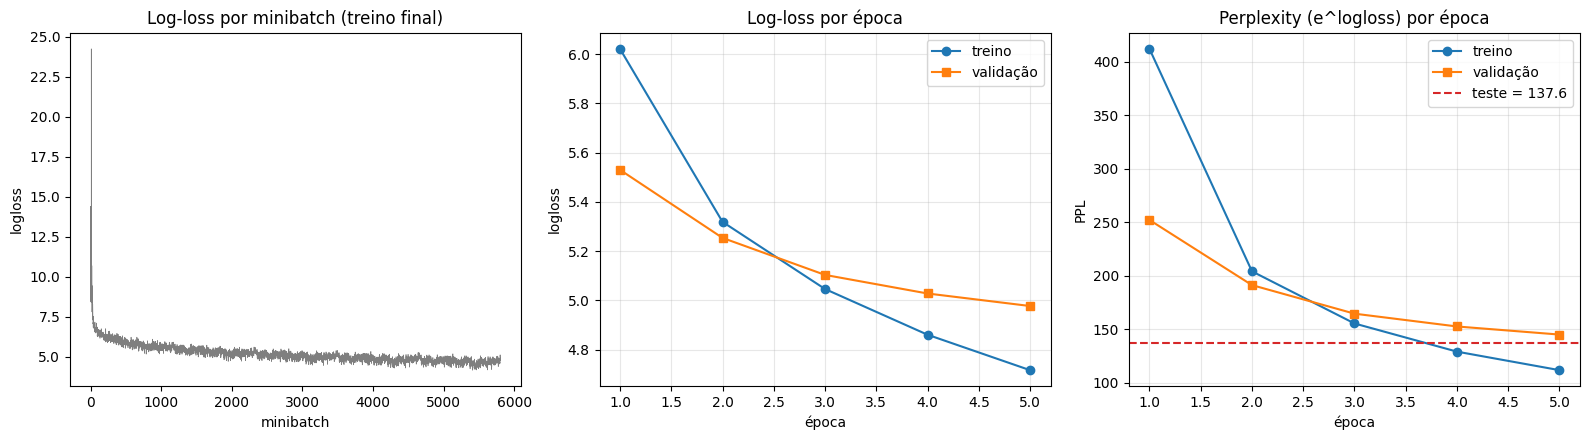

In [59]:
eixo_epocas = np.arange(1, len(historico["perda_tr"]) + 1)

fig, eixos = plt.subplots(1, 3, figsize=(16, 4.5))

# o primeiro mostra a perda de cada minibatch (dá pra ver o "tremido" do treino)
eixos[0].plot(historico["perda_passos"], lw=0.5, color="tab:gray")
eixos[0].set_title("Log-loss por minibatch (treino final)")
eixos[0].set_xlabel("minibatch"); eixos[0].set_ylabel("logloss")

# log-loss por época, treino vs validação
eixos[1].plot(eixo_epocas, historico["perda_tr"], "o-", label="treino")
eixos[1].plot(eixo_epocas, historico["perda_va"], "s-", label="validação")
eixos[1].set_title("Log-loss por época")
eixos[1].set_xlabel("época"); eixos[1].set_ylabel("logloss")
eixos[1].legend(); eixos[1].grid(alpha=0.3)

# a perplexity por época, com a linha do teste marcada
eixos[2].plot(eixo_epocas, historico["ppl_tr"], "o-", label="treino")
eixos[2].plot(eixo_epocas, historico["ppl_va"], "s-", label="validação")
eixos[2].axhline(ppl_te, color="tab:red", ls="--", label=f"teste = {ppl_te:.1f}")
eixos[2].set_title("Perplexity (e^logloss) por época")
eixos[2].set_xlabel("época"); eixos[2].set_ylabel("PPL")
eixos[2].legend(); eixos[2].grid(alpha=0.3)

fig.tight_layout()
os.makedirs("resultados", exist_ok=True)
fig.savefig(os.path.join("resultados", "curvas_treinamento.png"), dpi=130)
plt.show()

## 13. Analisando o modelo

Só a perplexity sozinha não conta a história toda, então olhei o modelo por uns ângulos
diferentes:

1. a PPL de treino, validação e teste lado a lado (e a diferença entre treino e validação, que
   dá uma ideia de quanto ele tá "decorando");
2. comparação com dois modelos burros de propósito: o chute aleatório e o unigrama (que só olha
   a frequência da palavra, ignora o contexto). Se a LSTM não ganhar deles, é porque não
   aprendeu nada de útil;
3. acurácia top-1 e top-5 (de quantas vezes a palavra certa tá entre os primeiros chutes);
4. o que ele chuta depois de algumas frases reais;
5. um textinho gerado por ele.

In [60]:
# 1) PPL nas três divisões
perda_tr_f, ppl_tr_f = avaliar(p, Xtr, Ytr, H, B, T)
perda_va_f, ppl_va_f = avaliar(p, Xva, Yva, H, B, T)
perda_te_f, ppl_te_f = avaliar(p, Xte, Yte, H, B, T)

print("conjunto     logloss   PPL = e^logloss")
print(f"treino       {perda_tr_f:7.4f}   {ppl_tr_f:8.2f}")
print(f"validação    {perda_va_f:7.4f}   {ppl_va_f:8.2f}")
print(f"teste        {perda_te_f:7.4f}   {ppl_te_f:8.2f}")
print(f"\ndiferença treino vs validação: {ppl_va_f - ppl_tr_f:.1f} de PPL")
print("(quanto menor essa diferença, menos ele decorou o treino)\n")

# 2) comparando com os baselines
contagens = np.bincount(ids_tr, minlength=V)        # quantas vezes cada palavra aparece no treino
prob_unigrama = contagens / contagens.sum()         # vira probabilidade (sem nenhum contexto)
logloss_uni = -np.log(prob_unigrama[ids_te]).mean()
ppl_uni = float(np.exp(logloss_uni))

print("modelo                        PPL no teste")
print(f"chute aleatório               {V:10.1f}")
print(f"unigrama (só frequência)      {ppl_uni:10.1f}")
print(f"minha LSTM                    {ppl_te_f:10.1f}   "
      f"({ppl_uni/ppl_te_f:.1f}x melhor que o unigrama)\n")

# 3) acurácia top-1 e top-5
acertos_top1, acertos_top5, total = 0, 0, 0
h = np.zeros((B, H), dtype=np.float32)
c = np.zeros((B, H), dtype=np.float32)
for inicio in range(0, Xte.shape[1], T):
    xb = Xte[:, inicio : inicio + T]
    yb = Yte[:, inicio : inicio + T]
    _, h, c, cache = forward(p, xb, yb, h, c, H)
    probs = cache["probs"]; alvos_1d = cache["alvos_1d"]
    top5 = np.argsort(probs, axis=1)[:, -5:]
    acertos_top1 += (top5[:, -1] == alvos_1d).sum()
    acertos_top5 += (top5 == alvos_1d[:, None]).any(axis=1).sum()
    total += len(alvos_1d)

print(f"acurácia top-1 no teste: {100 * acertos_top1 / total:.1f}% (acertou de primeira)")
print(f"acurácia top-5 no teste: {100 * acertos_top5 / total:.1f}% (a certa tava entre as 5)\n")

# 4) o que ele chuta depois de algumas frases
trechos = ["the federal government", "he said the", "in new york", "the company said it"]
for trecho in trechos:
    h1 = np.zeros((1, H), dtype=np.float32)
    c1 = np.zeros((1, H), dtype=np.float32)
    for palavra in trecho.split():
        probs, h1, c1 = prever_passo(p, palavra_para_id[palavra], h1, c1, H)
    melhores = probs.argsort()[-5:][::-1]
    sugestoes = ", ".join(f"{id_para_palavra[i]} ({100*probs[i]:.0f}%)" for i in melhores)
    print(f'"{trecho} ..." -> {sugestoes}')

# 5) gerando um texto (sorteando a próxima palavra a cada passo)
rng_amostra = np.random.default_rng(123)
h1 = np.zeros((1, H), dtype=np.float32)
c1 = np.zeros((1, H), dtype=np.float32)
atual = palavra_para_id["<eos>"]
geradas = []
for _ in range(50):
    probs, h1, c1 = prever_passo(p, atual, h1, c1, H)
    atual = int(rng_amostra.choice(V, p=probs))
    geradas.append(id_para_palavra[atual])
print("\ntexto gerado:")
print(" ".join(geradas))

conjunto     logloss   PPL = e^logloss
treino        4.6207     101.57
validação     4.9771     145.05
teste         4.9241     137.57

diferença treino vs validação: 43.5 de PPL
(quanto menor essa diferença, menos ele decorou o treino)

modelo                        PPL no teste
chute aleatório                  10000.0
unigrama (só frequência)           639.3
minha LSTM                         137.6   (4.6x melhor que o unigrama)

acurácia top-1 no teste: 22.4% (acertou de primeira)
acurácia top-5 no teste: 41.3% (a certa tava entre as 5)

"the federal government ..." -> <eos> (23%), to (11%), 's (10%), and (3%), in (3%)
"he said the ..." -> <unk> (16%), new (3%), company (1%), u.s. (1%), price (1%)
"in new york ..." -> <eos> (34%), city (24%), and (4%), when (2%), but (2%)
"the company said it ..." -> is (12%), would (8%), was (7%), 's (6%), will (5%)

texto gerado:
the <unk> <unk> <unk> <unk> that wants reconciliation support the ec 's recent bank polled by the brand of the N <unk> 

## 14. O que dá pra concluir

- A busca testou as combinações e escolheu sozinha a melhor, sem eu chutar no olho, e tudo
  com `for`, sem ferramenta pronta.
- A LSTM ganha bem fácil do chute aleatório (PPL 10000) e do unigrama (~600), então ela
  realmente aprendeu a usar o contexto, e não só a decorar quais palavras são comuns.
- A PPL de validação cai rápido nas primeiras épocas e depois vai desacelerando, e faz sentido,
  o ganho fácil (padrão local, tipo artigo antes de substantivo) vem primeiro.
- O early stopping serve justamente pra não deixar o modelo decorar o treino: ele guarda o
  melhor momento da validação e para quando não melhora mais.
- No texto gerado dá pra ver que ele monta uns pedaços com gramática ok, mesmo sem fazer muito
  sentido, mas é normal, modelo de linguagem fica bom de gramática antes de ficar bom de conteúdo.
  (Aparece bastante `<unk>` porque no PTB todas as palavras raras viram esse mesmo token, então
  ele acaba sendo um dos mais frequentes.)